<a href="https://colab.research.google.com/github/Tecnologico-de-Monterrey-MNA/nlp-2023-Equipo-4/blob/main/Equipo4_semana05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Maestría en Inteligencia Artificial Aplicada**
##**Curso TI4039.10 Estrategia de implementación de servicios tecnológicos (Gpo 10) : Procesamiento de Lenguaje Natural (NLP)**
###**Tecnológico de Monterrey**
###**Prof Luis Eduardo Falcón Morales**

## **Actividad en Equipos - Semana 5: Modelos Embebidos Caso Amazon/Yelp/IMDb**

###EQUIPO 4 

###Denisse Maria Ramirez Colmenero - A01561497

###Daniela Estévez Rodríguez - A01793723 

###Ernesto Nicanor Santillán Guerrero - A01793675

### José Ovalle Alvarado - A01150742

###Genaro Ramos Higuera - A00351269




En la actividad de esta semana trabajarás en equipos con el modelo de vectores continuos/embebidos FastText, es decir, el modelo desarrollado por Facebook en 2016.
Una manera de trabajar con estos modelos pre-entrenados, es generando el vocabulario a partir de tu conjunto de datos de entrenamiento. Para cada palabra de tu vocabulario, podrás sustituirlo por su correspondiente vector continuo. En caso de que no exista el vector para una palabra en particular, se puede eliminar dicha palabra, o bien sustituirla por el vector continuo más cercano. En esta actividad deberás aplicar esta segunda opción. Existen diversas propuestas para utilizar dichos vectores continuos como entrada para modelos de aprendizaje automático. En particular, en esta actividad cada enunciado será sustituido por el vector promedio de todos los tokens que lo forman.



####1. Descarga los 3 archivos de Canvas. En particular, el archivo de datos de IMDb ya no requiere transformarse para obtener sus 1000 registros. Al cargar los datos de los tres archivos deberás tener un DataFrame de Pandas de 3000 registros, con sus etiquetas. Los archivos los encuentras en Canvas y se llaman: amazon5.txt, imdb5.txt, yelp5.txt

In [ ]:
import pandas as pd  
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile



In [ ]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

###**Cargamos los datos**

In [ ]:
dfa = pd.read_csv('amazon5.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb5.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('yelp5.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (1000, 2)
Total de registros de Yelp: (1000, 2)


In [ ]:
print(dfa.info(),"\n")
print(dfi.info(),"\n")
print(dfy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   review  1000 non-null   object 
 1   label   0 non-null      float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


Observamos que en el archivo imdb5 , la columna label aparecen valores NaN , por lo que no se hizo la separacion correctamente 

In [ ]:
dfi.iloc[0:10]

,review,label
0,"A very, very, very slow-moving, aimless movie ...",NaN
1,Not sure who was more lost - the flat characte...,NaN
2,Attempting artiness with black & white and cle...,NaN
3,Very little music or anything to speak of. 0,NaN
4,The best scene in the movie was when Gerardo i...,NaN
5,"The rest of the movie lacks art, charm, meanin...",NaN
6,Wasted two hours. 0,NaN
7,Saw the movie today and thought it was a good ...,NaN
8,A bit predictable. 0,NaN
9,Loved the casting of Jimmy Buffet as the scien...,NaN


Procedemos a hacer la correccion para separar el valor de label de cada comentario

In [ ]:
tmpdfi = dfi.values.tolist()     # lista con los 1000 registros
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.

for i in range(len(tmpdfi)):
  new_item=[]
  new_item.append(tmpdfi[i][0][:-1])
  new_item.append(int(tmpdfi[i][0][-1]))
  newdfi.append(new_item)    


Ahora lo Transformamos en data frame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [ ]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
# y concatenamos los tres conjuntos para tener finalmente los 3000 registros:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [ ]:
df['label'].value_counts()   # Veamos que tenemos un 50% de comentarios positivos y de negativos.

0    1500
1    1500
Name: label, dtype: int64

In [ ]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [ ]:
 # Separamos la información: 
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, la evaluación.
 # Ambos, X y Y son "Series" 

X = df.review     # Serie de strings
Y = df.label      # Serie de enteros 0s y 1s

print(X.shape)       
print(Y.shape)

(3000,)
(3000,)


####2. Realiza de nuevo un proceso de limpieza. Aplica el preprocesamiento que consideres adecuado, sin embargo, deberás aplicar necesariamente alguna de las técnicas de lematización. Como aplicaremos modelos embebidos pre-entrenados, queremos palabras lo más cercanas a las existentes en un idioma, inglés en este caso. Aplica y justifica cualquier otro proceso de limpieza que consideres adecuado. Recuerda que en esta actividad se usarán vectores embebidos para un problema de clasificación, por lo que deberás tomar de acuerdo a este contexto. Justifica todas las transformaciones que se apliquen.

In [ ]:
def clean_tok(doc):
  #Se considera para la limpieza:
  #Solo caracteres alfabéticos. 
  #Por lo que serán eliminados signos de puntuación, caracteres especiales y números.
  #Se consideran solamente tokens de longitud mayor a 1.
  #y lo simplificamos todo a minúsculas.
  #y eliminamos las stopwords.
  #Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

  words = re.findall(r"\w*(?:[a-zA-Z]{2,})",doc)
  tokens=[]
  for x in words:
    if x.lower() not in stopwords.words('english'):
      tokens.append(x.lower())    

  return tokens

In [ ]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]   

In [ ]:

# Ahora aplicaremos un proceso de limpieza adicional
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wnl = WordNetLemmatizer() # creamos un objeto de la clase WordNetLemmatizer

import nltk
from nltk.stem import PorterStemmer   
nltk.download('omw-1.4')  
ps = PorterStemmer() # creamos un objeto de la clase PorterStemmer


def clean_doc(doc):
  words_clean1=[wnl.lemmatize(w, pos='v') for w in doc]#Primero hacemos el proceso de Lematizacion considerando el parametro pos=`v'
  tokens=[ps.stem(w) for w in words_clean1]#luego aplicamos Stematizacion 

  return tokens
  

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]  

In [ ]:
Xclean[0:20]         # Veamos los primero registros para ver cómo va quedando el resultado.

[['way', 'plug', 'us', 'unless', 'go', 'convert'],
 ['good', 'case', 'excel', 'valu'],
 ['great', 'jawbon'],
 ['tie', 'charger', 'convers', 'last', 'minut', 'major', 'problem'],
 ['mic', 'great'],
 ['jiggl', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volum'],
 ['sever',
  'dozen',
  'sever',
  'hundr',
  'contact',
  'imagin',
  'fun',
  'send',
  'one',
  'one'],
 ['razr', 'owner', 'must'],
 ['needl', 'say', 'wast', 'money'],
 ['wast', 'money', 'time'],
 ['sound', 'qualiti', 'great'],
 ['impress', 'go', 'origin', 'batteri', 'extend', 'batteri'],
 ['two',
  'seper',
  'mere',
  'ft',
  'start',
  'notic',
  'excess',
  'static',
  'garbl',
  'sound',
  'headset'],
 ['good', 'qualiti', 'though'],
 ['design', 'odd', 'ear', 'clip', 'comfort'],
 ['highli', 'recommend', 'one', 'blue', 'tooth', 'phone'],
 ['advis', 'everyon', 'fool'],
 ['far', 'good'],
 ['work', 'great'],
 ['click',
  'place',
  'way',
  'make',
  'wonder',
  'long',
  'mechan',
  'would',
  'last']]

Ya que es un dataset de 3000 registros, cada uno con diversa cantidad de tokens, se trato de modificar los tokens de los reviews con distintos procesos de limpieza, hacerlo más general, y que no existieran tantas palabras diferentes para así al momento de crear el diccionario no sean tantas palabras y ocurra un sobreentreno.

####3.- Llamar Xclean a los comentarios procesados y Y a las etiquetas. Realicemos una partición aleatoria con los mismos porcentajes de la práctica pasada para poder comparar dichos resultados con los de esta actividad, a saber, 70%, 15% y 15%, para entrenamiento, validación y prueba, respectivamente. Verifica que obtienes 2100 registros de entrenamiento y 450 para cada uno de validación y prueba.


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, Y, train_size=.70, shuffle=True, random_state=1) 
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=17)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


####4. Usando el conjunto de entrenamiento genera un vocabulario que no sea mayor a 1500 palabras, ni menor a 1000. ¿Por qué es importante acotar un vocabulario inferior y superiormente? ¿Por qué debe usarse solamente el conjunto de entrenamiento para generar el diccionario? Con este vocabulario que obtienes, filtra los conjuntos de entrenamiento, validación y prueba, de esta manera todos los comentarios usarán solamente palabras válidas de acuerdo a este vocabulario. Indica el tamaño del vocabulario obtenido.
Hasta este punto básicamente has realizado transformaciones muy análogas a las de la semana pasada y que son válidas para muchos de los procesos dentro del análisis de textos. En dado caso comenta con tus compañeros de equipo qué diferencias has observado. Veamos ahora la diferencia con respecto a las matrices Tf-idf que aplicaste la semana pasada, con respecto a los vectores pre- entrenados embebidos.

In [ ]:
from collections import Counter

In [ ]:
midiccionario = Counter()    

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))  
print('\n(word,frequency):') 
print(midiccionario.most_common(20)) 

Longitud del diccionario: 3104

(word,frequency):
[('good', 164), ('movi', 140), ('great', 139), ('phone', 134), ('film', 130), ('work', 113), ('time', 102), ('like', 101), ('one', 100), ('go', 89), ('place', 87), ('servic', 86), ('food', 84), ('get', 84), ('make', 82), ('bad', 74), ('realli', 71), ('use', 66), ('love', 66), ('well', 59)]


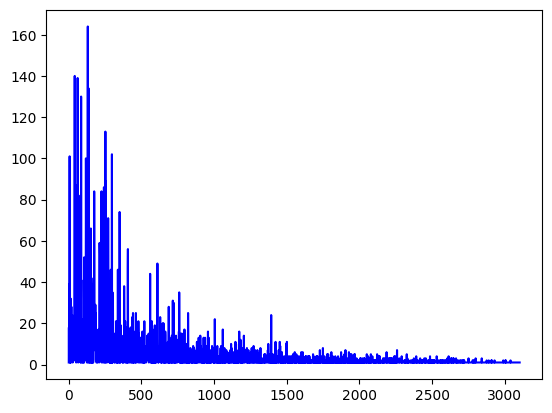

In [ ]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:
import matplotlib.pyplot as plt
plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartamos ahora palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

In [ ]:
#consideramos la minima frecuencia:
min_freq = 2

midicc ={}      
for x in midiccionario.keys():
  if midiccionario[x] >= min_freq:
     midicc[x]=midiccionario[x]

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:20])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 1412
[('star', 18), ('fare', 2), ('much', 39), ('better', 38), ('peopl', 23), ('like', 101), ('morgan', 2), ('ed', 3), ('wast', 32), ('tonight', 2), ('filet', 2), ('special', 13), ('suck', 28), ('pay', 9), ('bill', 3), ('tip', 5), ('felt', 11), ('server', 15), ('terribl', 24), ('job', 13)]


###Filtramos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [ ]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [ ]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después 
# de incluir la condición de la frecuencia mínima de ocurrencia de un token:

for k in range(5):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['co', 'star', 'fare', 'much', 'better', 'peopl', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'wast']
Después: ['star', 'fare', 'much', 'better', 'peopl', 'like', 'morgan', 'ed', 'wast']
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['tonight', 'filet', 'special', 'suck']
Antes: ['pay', 'bill', 'tip', 'felt', 'server', 'terribl', 'job']
Después: ['pay', 'bill', 'tip', 'felt', 'server', 'terribl', 'job']
Antes: ['call', 'steakhous', 'properli', 'cook', 'steak', 'understand']
Después: ['call', 'properli', 'cook', 'steak', 'understand']
Antes: ['howev', 'keypad', 'tinni', 'sometim', 'reach', 'wrong', 'button']
Después: ['howev', 'keypad', 'tinni', 'sometim', 'reach', 'wrong', 'button']


Ahora ponemos cada comentario esté como un solo string.

In [ ]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verifica que los primeros comentarios de Train están cada uno como un solo string:
for k in range(5):
  print(train_x_docs[k])

star fare much better peopl like morgan ed wast
tonight filet special suck
pay bill tip felt server terribl job
call properli cook steak understand
howev keypad tinni sometim reach wrong button


**¿Por qué es importante acotar un vocabulario inferior y superiormente?**

Si el vocabulario está muy acotado no tendrá suficientes palabras y el modelo no tendrá un buen ajuste, por el contrario si el vocabulario tiene demasiadas palabras se generarán muchos vectores por analizar que no aporten suficiente información al modelo y serán vectores con poco aporte al modelo pero sí con carga de procesamiento.

**¿Por qué debe usarse solamente el conjunto de entrenamiento para generar el diccionario?**

Por filtrado de información, si los datos de validación o prueba se filtran o se analizan previamente, no se tendrá certeza si el desempeño de los modelos es realmente bueno, y además se puede correr el riesgo de tener sobreajuste en el modelo.

####5. Utilizarás los vectores embebidos FastText preentrenados por Facebook.
a. Incluye una tabla comparativa de pros y contras entre los modelos FastText, word2vec de
Google y Glove de Stanford. Puedes consultar sus páginas correspondientes:

https://fasttext.cc/ 

https://code.google.com/archive/p/word2vec/

https://nlp.stanford.edu/projects/glove/


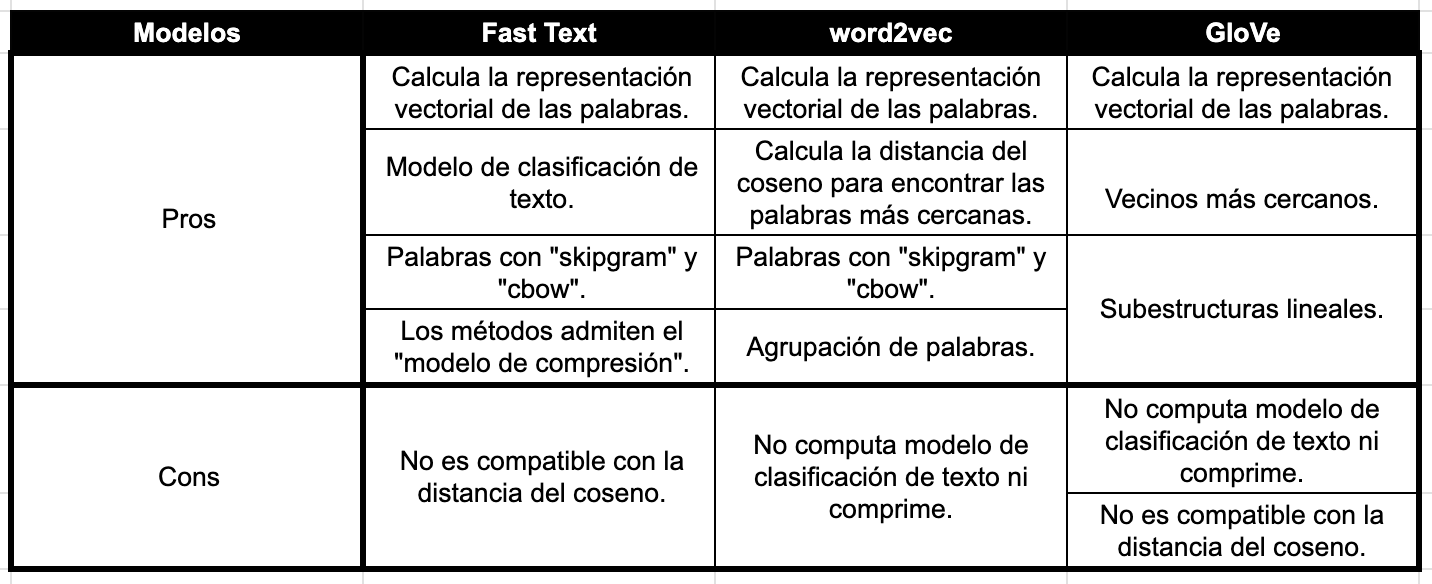

6.- Utiliza el modelo FastText de vectores embebidos pre-entrenados de dimensión 300 para generar un nuevo diccionario clave-valor, donde la “clave” será cada token o palabra de tu vocabulario y el “valor” será su vector embebido de dimensión 300. Este diccionario deberá ser del mismo tamaño que el vocabulario previo que hayas construido previamente.
https://fasttext.cc/docs/en/crawl-vectors.html

In [ ]:
pip install fasttext

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-2.10.4-py3-none-any.whl (222 kB)
  Created wheel for fasttext: filename=fasttext-0.9.2-cp310-cp310-linux_x86_64.whl size=4393229 sha256=459956070e14393e12a0b97567ae593c2752b56af4b09bbd545e5a15e29420d5
  Stored in directory: /root/.cache/pip/wheels/a5/13/75/f811c84a8ab36eedbaef977a6a58a98990e8e0f1967f98f394
Successfully built fasttext


In [ ]:
import fasttext
import fasttext.util

In [ ]:
fasttext.util.download_model('en', if_exists='ignore')  # English

'cc.en.300.bin'

In [ ]:
ft = fasttext.load_model('cc.en.300.bin')

In [ ]:
midicc_vec={}

In [ ]:
for token in midicc.keys():
  vector=ft.get_word_vector(token)
  midicc_vec.update({token:vector})



In [ ]:
#Salvamos el dicctionario con los tokens y vectores
np.save('midicc_vec.npy', midicc_vec)

In [ ]:
#veamos los primeros 3 token del diccionario y su vector
i=0 
for token in midicc_vec.keys():
  print("Token: ", token, midicc_vec[token])
  i=i+1
  if i>2:
    break

Token:  star [-2.86828041e-01  1.15123533e-01  5.38213179e-02  6.26803637e-02
  2.47128960e-02 -2.57342309e-02  1.47269234e-01 -1.16852485e-01
  1.43789779e-02  2.02018499e-01 -6.00243136e-02 -6.75183982e-02
 -4.77372715e-03  4.89413664e-02  1.16688116e-02 -3.23957461e-03
 -1.23359617e-02 -8.51226449e-02 -4.92033921e-02  6.35383427e-02
  8.86741839e-03  1.40952796e-01  1.09847665e-01  1.25429276e-02
 -4.25020084e-02 -8.08417723e-02  2.70867231e-03  3.24510969e-02
  1.41084492e-02  1.06206566e-01  1.08138800e-01 -5.41383438e-02
  5.69636673e-02  5.37327491e-02 -7.06092343e-02 -9.78406295e-02
 -1.20484188e-01 -4.16465327e-02 -8.21356028e-02  4.71536033e-02
  9.90687776e-03  4.89758067e-02 -1.33870468e-01 -1.54928997e-01
 -1.81018680e-01  1.78726465e-02  7.79893203e-03 -8.59202892e-02
 -2.29937509e-02 -1.81513757e-01 -1.04256801e-01  1.19395129e-01
  7.99314678e-03  5.44246733e-02  1.18487053e-01  4.88866717e-02
  5.15220016e-02 -4.63055186e-02  8.03847145e-03 -5.37553839e-02
 -1.83139741

In [ ]:
del ft#para liberar espacio en memoria

In [ ]:
import pickle

with open("midicc_vec.pkl", "wb") as tf:
    pickle.dump(midicc_vec,tf)

####7. Una manera de utilizar los vectores embebidos con modelos de aprendizaje automático en documentos de texto, es asignar a cada comentario filtrado el vector embebido de dimensión 300 que resulta de promediar todos sus tokens. Así, en este ejercicio deberás generar los arreglos correspondientes para los conjuntos de entrenamiento, validación y prueba. Los llamaremos trainEmb, valEmb y testEmb, respectivamente. ¿Cuáles son sus dimensiones? ¿Se podrían usar para su representación matrices dispersas (sparse matrices) como en el caso de la matriz Tf-idf? Responde a dichas preguntas.

In [ ]:
#Creamos una funcion para obtener estos vectores promedio por cada comentario

def get_doc_vector(docs):
  arrays_list=[]
  for doc in docs:
    array_doc=np.zeros((300,))
    tokens=doc.split()
    
    for word in tokens:
      array_word = midicc_vec[word]
      array_doc=array_doc+array_word

    if len(tokens) !=0:#para asignar un valor cuando exista al menos una palabra en el comentario
                       #de lo contrario seran zeros
      array_doc=array_doc/len(tokens)#asignamos el promedio
    arrays_list.append(array_doc)
  return np.array(arrays_list)

In [ ]:
trainEmb=get_doc_vector(train_x_docs)

In [ ]:
print(trainEmb.shape)#dimension de trainEmb

(2100, 300)


In [ ]:
valEmb=get_doc_vector(val_x_docs)#dimensiones de Val

In [ ]:
print(valEmb.shape)#dimension de valEmb

(450, 300)


In [ ]:
testEmb=get_doc_vector(test_x_docs)

In [ ]:
print(testEmb.shape)#dimension de testEmb

(450, 300)


***¿Se podrían usar para su representación matrices dispersas (sparse matrices) como en el caso de la matriz Tf-idf? ***

No, ya que la vectorización que estamos utilizando tiene un vector de dimensión 300 que da un valor a cada token, por lo que la matriz obtenida con los vectores es una matriz densa en el que cada valor es importante y la utilizaremos para promediar los vectores de cada token en cada comentario y no requiere usarse la sparse matrix ya que no hay presencia de muchos ceros.
En la matriz tfidf cada comentario tiene todos los tokens por columna y por eso hay muchos ceros, aqui es diferente, cada token sólo aporta valor al vector promedio del comentario.

###8. Utiliza los modelos de regresión logística y bosque aleatorio (random forest) y encuentra sus desempeños (accuracy). Compara los resultados con los de la semana anterior

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


### Buscaremos antes los mejores hiperparametros en cada modelo:

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# grid parametros para buscar en LogisticRegression
grid_parameters = {'C': [.000001, .00001, .0001, .001, 0.01,.05,.1, 0.5, 1,1.1, 2,10],
    'solver'  : ['newton-cg','liblinear', 'lbfgs'],
    'penalty': ['l1','l2']}


In [ ]:
modeloLR = LogisticRegression(max_iter=1000,n_jobs=-1)
grid_search = GridSearchCV(modeloLR,                    # modelo
                   param_grid = grid_parameters,   # hiperparameters
                   scoring='accuracy',        # metrica scoring
                   cv=10)                     # numero de folds

In [ ]:
grid_search.fit(trainEmb, y_train)


GridSearchCV(cv=10, estimator=LogisticRegression(max_iter=1000, n_jobs=-1),
             param_grid={'C': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 1.1,
                               10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [ ]:
print("Mejores Hiperparámetros :", grid_search.best_params_)
print("Accuracy :",grid_search.best_score_)

Mejores Hiperparámetros : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy : 0.7666666666666667


Mejores Hiperparámetros : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy : 0.7666666666666667

In [ ]:
# grid parametros para buscar en RandomForest
grid_parameters = {'n_estimators': [2,4,6,8,10,12,14,16,18,20,24,30,31],
    'criterion'  : ['entropy'],
    'max_depth': [2,3,4],
    'min_samples_leaf' : [2],
    'min_samples_split' : [2],
    'max_features':['log2']}


In [ ]:
modeloRF = RandomForestClassifier(n_jobs=-1,random_state=0)
grid_search = GridSearchCV(modeloRF,                    # modelo
                   param_grid = grid_parameters,   # hiperparameters
                   scoring='accuracy',        # metrica scoring
                   cv=5)                     # numero de folds

In [ ]:
grid_search.fit(trainEmb, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=0),
             param_grid={'criterion': ['entropy'], 'max_depth': [2, 3, 4],
                         'max_features': ['log2'], 'min_samples_leaf': [2],
                         'min_samples_split': [2],
                         'n_estimators': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20,
                                          24, 30, 31]},
             scoring='accuracy')

In [ ]:
print("Mejores Hiperparámetros :", grid_search.best_params_)
print("Accuracy :",grid_search.best_score_)

Mejores Hiperparámetros : {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 31}
Accuracy : 0.7080952380952381


Después muchas horas de probar diferentes Grids de Parámetros nos dimos cuenta de darle mucha profundidad y utilizar muchos estimadores el modelo mejoraba el accuracy con datos de Training a niveles de 85-95% pero con datos de  Validation  se sobreentrenaba demasiado y caía a niveles del 70-75% lo que nos daba diferencias de más del 10%-15%; por lo que decidimos no darle mucha profundidad (max_depth) y utilizar un numero relativamente pequeño de estimadores.


In [ ]:
##############################################################################

modeloLR = LogisticRegression(max_iter=8000, C=1, penalty='l2', solver='liblinear',n_jobs=-1)
modeloLR.fit(trainEmb, y_train)

modeloRF = RandomForestClassifier(criterion='entropy', max_depth=4, max_features='log2',
                                  min_samples_leaf=2,min_samples_split=2,
                                  n_estimators=31, random_state=0)
modeloRF.fit(trainEmb, y_train)

##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLR.score(trainEmb, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLR.score(valEmb, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRF.score(trainEmb, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRF.score(valEmb, y_val)))



LR: Train-accuracy: 79.95%
LR: Val-accuracy: 78%

RF: Train-accuracy: 80.38%
RF: Val-accuracy: 74.89%


Nos resulta que el modelo de LogisticRegression es un modelo adecuadamente entrenado, tenemos una diferencia de accuracy  no mayor al 2% entre Train-Accuracy y Val-Accuracy, del 79.95% y del 78% respectivamente. 

El Modelo de Random Forest nos da un modelo ligeramente SobreEntrenado ya que tenemos una diferencia de accuracy del 5.49% entre Train-Accuracy y Val-Accuracy , del 80.38% y del 74.89% respectivamente. 

Por lo que escogemos usar como mejor modelo el de LogisticRegression por estar debidamente entrenado. 

En ambos casos en el ejercicio anterior: Buscamos que el accuracy en Val fuera el mas alto, sin embargo , debimos de buscar modelo NO SOBREENTRENADOS con una diferencia de accuracy menor a 2% entre Training y Validation, ya que la semana anterior vimos que los modelos nos daban los siguientes resultados usando las matrices de conteo:

LR: Train-accuracy: 77%-97%

LR: Val-accuracy: 75%-81%

RF: Train-accuracy: 75%-92%

RF: Val-accuracy: 72%-80%







###9.Obtener la matriz de confusión e interpretar sus valores.

Test-accuracy con el mejor modelo de Conteo 79.78%

Matriz de confusión con el mejor modelo de Conteo:
[[173  43]
 [ 48 186]]


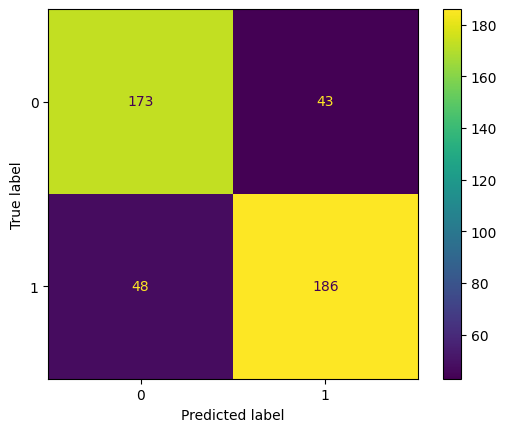


Matriz de confusión con el mejor modelo de Conteo en proporciones:
[[0.38444444 0.09555556]
 [0.10666667 0.41333333]]


In [ ]:
# EL mejor modelo LR por que vemos que no esta sobreentrenado y sus resultados son 
mejor_modelo= modeloLR



print('Test-accuracy con el mejor modelo de Conteo %.2f%%' % (100*mejor_modelo.score(testEmb, y_test)))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = mejor_modelo.predict(testEmb)
print('\nMatriz de confusión con el mejor modelo de Conteo:')
print(confusion_matrix(y_test, pred, labels=[0,1]))
cm = confusion_matrix(y_test, pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])
disp.plot()

plt.show()
print('\nMatriz de confusión con el mejor modelo de Conteo en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Utilizando el modelo de Regresión Logística, podemos observar que tenemos un porcentaje de valores predecidos correctamente de 79.78% aproximadamente.Se nota un modelo debidamente entrenado ya que el accuracy permanece casi igual del 79.95% en training y ahora con test baja ligeramente a 79.78%.

En la mayoría de los resultados de la actividad anterior de los integrantes del equipo, el resultado de esta matriz de confusión es casi la misma.

En este caso, los porcentajes de Falsos Positivos y Falsos Negativos también son muy similares (9.55% y 10.67%), esto nos indica que el modelo tiene una tasa de error muy similar para ambos casos: y no puede distinguir cuando predice un comentario positivo cuando en realidad es un comentario negativo, Falsos Positivos=43, el 9.55%; y cuando predice un comentario negativo cuando en realidad es un comentario positivo, Falsos Negativos=48, el 10.67%.


###10. Comenta con tus compañeros de equipo los pasos realizados en esta actividad e incluyan sus conclusiones finales


Vemos que FastText nos ayuda a utilizar una representacion vectorial de las palabras o tokens en un comentario o documento.

Podemos utilzar estos vectores para calcular el peso de cada token en cada comentario y promediar su vector fasttext , que en este ejercicio utilizamos un vector de dimension (300,).

Utilizamos un modelo de Logistic Regression adecuadamente entrenado para hacer predicciones y nos entregó un resultado de test-accuracy del 79.78%.

Vimos que una tasa de error muy similar para ambos casos de Falsos Positivos y Falsos Negativos: cuando predice un comentario positivo cuando en realidad es un comentario negativo, Falsos Positivos=43, el 9.55%; y cuando predice un comentario negativo cuando en realidad es un comentario positivo, Falsos Negativos=48, el 10.67%.

Se podrían obtener mejores resultados y modelos con mayor cantidad de comentarios. Adicionalmente con un dataset mayor/más grande, se pueden utilizar modelos más complejos como RNN y Transformers.

Este método puede ser utilizado en aplicaciones de la vida real en lugar de utilizar a personas en tareas repetitivas y tediosas como el clasificar comentarios de redes sociales, y aprovechar a dichas personas para tareas estratégicas de la empresa u organización.





#**FIN DE LA ACTIVIDAD EQUIPO DE LA SEMANA 05**